# Module 1 — Data Foundation
### CineStream Content Analytics — OJT Self Project

**Goal:** Load the raw CineStream catalog, understand its structure, and identify data quality issues that must be fixed before analysis (Module 2 — Cleaning).

**Stack used:** pandas, numpy, matplotlib, plotly (same as Proj 4.1 — Superstore)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load the Dataset

In [2]:
df = pd.read_csv("../data/CineStream_Catalog.csv")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 524, Columns: 23


,ContentID,Title,Type,Genre,Language,Country,Director,CastCount,ReleaseYear,AddedDate,RuntimeMinutes,EpisodeCount,AgeRating,IMDbScore,ViewsMillions,WatchHoursMillions,AvgCompletionPct,AwardsWon,ProductionCostCr,RevenueCr,SubscribersGainedThousands,TrendingStatus,CriticRating
0,CS-0001,Voyage Whispering II,Movie,Kids,Hindi,India,Akira Brown,3,2024,2020-04-28,149,1,U/A 13+,8.0,25.28,40.81,65,4,56.1,59.5,5873,Classic,7.4
1,CS-0002,Endless River: Reborn,Series,Kids,Korean,South Korea,Riya Patel,6,2017,2020-07-30,880,16,U/A 7+,6.8,24.13,244.20,69,0,43.6,33.6,-1000,New,6.2
2,CS-0003,Distant Letter of the North,Series,Romance,Telugu,India,Liam Iyer,4,2016,2020-08-29,300,12,U/A 16+,7.7,26.77,107.08,80,2,63.6,56.6,1016,Popular,6.9
3,CS-0004,Light Whispering,Series,Animation,English,Australia,Min-jun Khan,5,2020,2020-02-16,1400,40,U/A 7+,5.6,8.67,111.27,55,0,44.3,8.6,-1000,Trending,6.6
4,CS-0005,Game Quiet III,Stand-up,Comedy,Hindi,India,Yuki Yilmaz,13,2017,2021-04-20,87,1,U/A 13+,5.5,7.01,5.29,52,0,1.7,10.6,1976,Classic,4.8


## 2. Column Overview & Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ContentID                   524 non-null    str    
 1   Title                       524 non-null    str    
 2   Type                        524 non-null    str    
 3   Genre                       524 non-null    str    
 4   Language                    524 non-null    str    
 5   Country                     524 non-null    str    
 6   Director                    520 non-null    str    
 7   CastCount                   524 non-null    int64  
 8   ReleaseYear                 524 non-null    int64  
 9   AddedDate                   521 non-null    str    
 10  RuntimeMinutes              524 non-null    int64  
 11  EpisodeCount                524 non-null    int64  
 12  AgeRating                   524 non-null    str    
 13  IMDbScore                   524 non-null    fl

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ContentID,524,520,CS-0159,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title,524,504,Silent City,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,524,7,Movie,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Genre,524,19,Thriller,65,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,524,17,Hindi,122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,524,9,India,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Director,520,300,Various,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CastCount,524.0,NaN,NaN,NaN,8.76145,3.801776,3.0,5.0,9.0,12.0,15.0
ReleaseYear,524.0,NaN,NaN,NaN,2019.465649,2.856806,2015.0,2017.0,2019.5,2022.0,2024.0
AddedDate,521,450,2023-03-22,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values

Checking every column for nulls to understand which fields need attention in the cleaning module.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

Director     4
AddedDate    3
dtype: int64

**Finding:** `Director` and `AddedDate` have a small number of missing values. These will need to be handled in Module 2 (e.g. filling `Director` with "Unknown", or dropping/imputing `AddedDate`).

## 4. Duplicate Records

In [6]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate ContentID values:", df['ContentID'].duplicated().sum())
df[df.duplicated(keep=False)].sort_values('ContentID').head(10)

Duplicate rows: 4
Duplicate ContentID values: 4


,ContentID,Title,Type,Genre,Language,Country,Director,CastCount,ReleaseYear,AddedDate,RuntimeMinutes,EpisodeCount,AgeRating,IMDbScore,ViewsMillions,WatchHoursMillions,AvgCompletionPct,AwardsWon,ProductionCostCr,RevenueCr,SubscribersGainedThousands,TrendingStatus,CriticRating
158,CS-0159,Garden Sacred of the North,Movie,Drama,Korean,South Korea,Mira Smith,4,2023,2021-06-24,156,1,U/A 13+,7.8,29.49,56.74,74,2,45.4,37.5,4861,Classic,7.9
522,CS-0159,Garden Sacred of the North,Movie,Drama,Korean,South Korea,Mira Smith,4,2023,2021-06-24,156,1,U/A 13+,7.8,29.49,56.74,74,2,45.4,37.5,4861,Classic,7.9
206,CS-0207,Bridge Bright,Documentary,Romance,Hindi,India,Aylin Yilmaz,15,2022,2023-08-21,66,1,U,7.5,12.18,9.51,71,2,10.7,20.2,2185,New,5.5
521,CS-0207,Bridge Bright,Documentary,Romance,Hindi,India,Aylin Yilmaz,15,2022,2023-08-21,66,1,U,7.5,12.18,9.51,71,2,10.7,20.2,2185,New,5.5
210,CS-0211,Silent Mountain II,Movie,Action,Turkish,Turkey,Diego Jones,10,2017,2022-10-18,159,1,U/A 13+,6.3,20.00,34.45,65,2,27.0,45.6,4630,New,4.8
523,CS-0211,Silent Mountain II,Movie,Action,Turkish,Turkey,Diego Jones,10,2017,2022-10-18,159,1,U/A 13+,6.3,20.00,34.45,65,2,27.0,45.6,4630,New,4.8
517,CS-0518,Endless Light of the Lost,Movie,Sci-Fi,Spanish,Spain,Asha Kim,4,2020,2022-11-13,153,1,U/A 16+,6.9,9.94,18.00,71,0,29.6,13.0,7420,Classic,4.2
520,CS-0518,Endless Light of the Lost,Movie,Sci-Fi,Spanish,Spain,Asha Kim,4,2020,2022-11-13,153,1,U/A 16+,6.9,9.94,18.00,71,0,29.6,13.0,7420,Classic,4.2


**Finding:** There are duplicate rows in the catalog (same `ContentID` appearing more than once). These need to be removed in Module 2, keeping only one record per title.

## 5. Categorical Column Consistency

Checking for inconsistent casing, whitespace, and category naming — common issues in raw data exports.

In [7]:
for col in ['Type', 'Genre', 'Language', 'AgeRating', 'TrendingStatus']:
    print(f"--- {col} ---")
    print(sorted(df[col].unique()))
    print()

--- Type ---
['Documentary', 'Movie', 'Series', 'Stand-up', 'documentary', 'movie', 'series']

--- Genre ---
['Action', 'Action ', 'Animation', 'Comedy', 'Comedy ', 'Drama', 'Drama ', 'Horror', 'Horror ', 'Kids', 'Kids ', 'Reality', 'Reality ', 'Romance', 'Romance ', 'Sci-Fi', 'Sci-Fi ', 'Thriller', 'Thriller ']

--- Language ---
['Bengali', 'English', 'English ', 'Hindi', 'Hindi ', 'Japanese', 'Kannada', 'Kannada ', 'Korean', 'Malayalam', 'Spanish', 'Tamil', 'Tamil ', 'Telugu', 'Telugu ', 'Turkish', 'Turkish ']

--- AgeRating ---
['A', 'U', 'U/A 13+', 'U/A 16+', 'U/A 7+']

--- TrendingStatus ---
['Classic', 'New', 'Popular', 'Trending']



**Findings:**
- `Type` has inconsistent casing: `'Movie'` vs `'movie'`, `'Series'` vs `'series'`, `'Documentary'` vs `'documentary'`.
- `Genre` and `Language` have entries with trailing whitespace, e.g. `'Action '` vs `'Action'`, `'Hindi '` vs `'Hindi'` — these are being treated as separate categories but are really the same value.
- These must be standardized (trim whitespace, unify casing) in Module 2, otherwise genre/language groupings in the dashboard will be split incorrectly.

## 6. Numeric Range Checks (Outliers & Invalid Values)

In [8]:
print("IMDbScore range:", df['IMDbScore'].min(), "-", df['IMDbScore'].max())
print("CriticRating range:", df['CriticRating'].min(), "-", df['CriticRating'].max())
print("RuntimeMinutes range:", df['RuntimeMinutes'].min(), "-", df['RuntimeMinutes'].max())
print("SubscribersGainedThousands range:", df['SubscribersGainedThousands'].min(), "-", df['SubscribersGainedThousands'].max())

IMDbScore range: 3.7 - 11.4
CriticRating range: 1.7 - 12.9
RuntimeMinutes range: 50 - 99999
SubscribersGainedThousands range: -50000 - 11636


In [9]:
# IMDb is normally scored 0-10, CriticRating typically 0-10 as well
print("Titles with IMDbScore > 10:", (df['IMDbScore'] > 10).sum())
print("Titles with CriticRating > 10:", (df['CriticRating'] > 10).sum())
print("Titles with RuntimeMinutes > 500 (likely bad data):", (df['RuntimeMinutes'] > 500).sum())
print("Titles with negative SubscribersGainedThousands:", (df['SubscribersGainedThousands'] < 0).sum())

Titles with IMDbScore > 10: 3
Titles with CriticRating > 10: 2
Titles with RuntimeMinutes > 500 (likely bad data): 76
Titles with negative SubscribersGainedThousands: 81


**Findings:**
- A handful of titles show `IMDbScore` or `CriticRating` above 10 — outside the valid 0–10 scale, likely data-entry errors.
- `RuntimeMinutes` has extreme outliers (e.g. a value of 99999), which is clearly invalid for a single title.
- 81 titles show a **negative** `SubscribersGainedThousands` — this is plausible (a title can *cause* subscriber churn), but the magnitude of some values needs sanity-checking against the rest of the distribution.
- These will require capping, correction, or flagging in Module 2.

## 7. Quick Visual Exploration

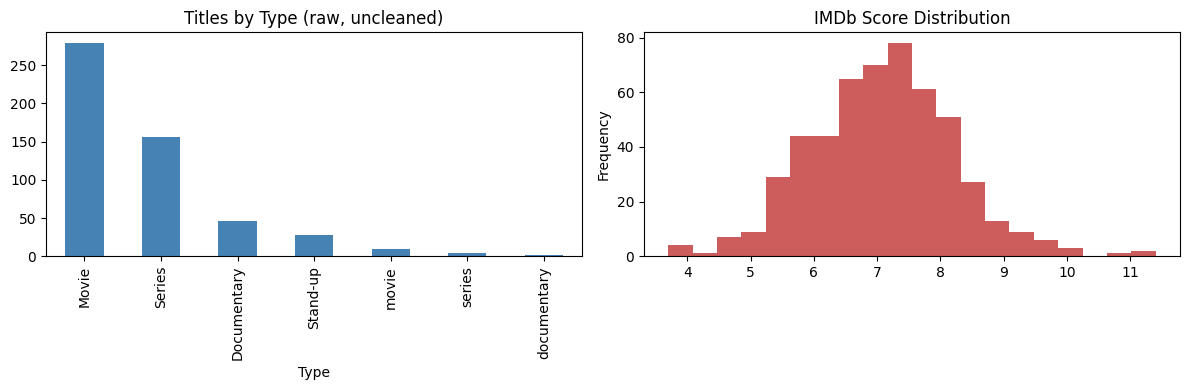

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Titles by Type (raw, uncleaned)')
df['IMDbScore'].plot(kind='hist', bins=20, ax=axes[1], color='indianred')
axes[1].set_title('IMDb Score Distribution')
plt.tight_layout()
plt.show()

In [11]:
fig = px.scatter(df, x='ProductionCostCr', y='RevenueCr', color='Type',
                  title='Production Cost vs Revenue (raw data)',
                  labels={'ProductionCostCr': 'Production Cost (Cr)', 'RevenueCr': 'Revenue (Cr)'})
fig.show()

## 8. Summary — What Needs Fixing in Module 2 (Cleaning)

| Issue | Action Needed |
|---|---|
| Missing `Director`, `AddedDate` values | Impute or flag as "Unknown" |
| Duplicate rows / `ContentID`s | Drop duplicates |
| Inconsistent casing in `Type` | Standardize to Title Case |
| Trailing whitespace in `Genre`, `Language` | Strip whitespace |
| `IMDbScore` / `CriticRating` > 10 | Cap or investigate as data errors |
| `RuntimeMinutes` extreme outliers | Cap or remove implausible values |
| Negative `SubscribersGainedThousands` | Validate against expected range, keep if legitimate churn signal |

This concludes Module 1 — Data Foundation. Module 2 will apply these fixes and produce `cleaned_cinestream.csv`.